In [115]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [116]:
df = pd.read_csv('house_price.csv')

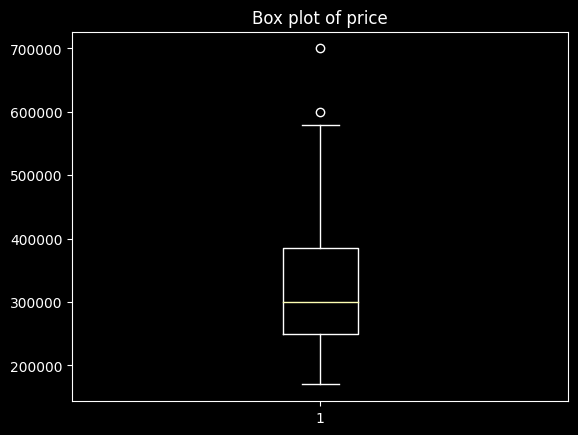

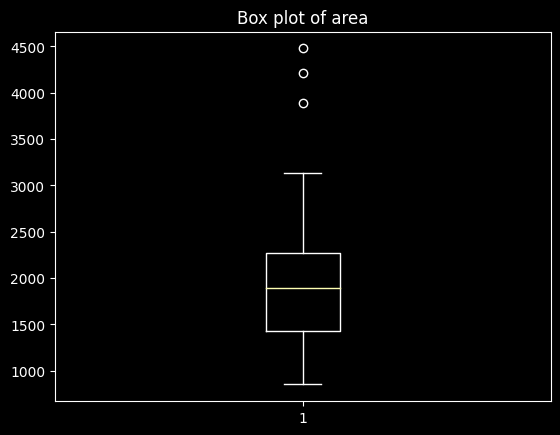

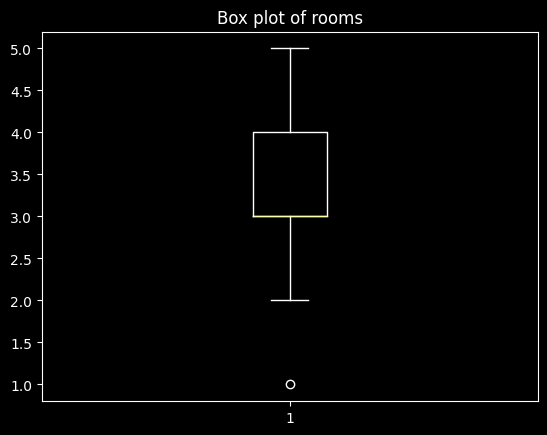

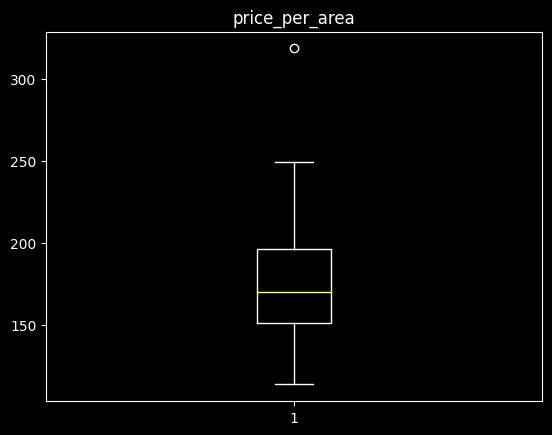

In [117]:
df['price_per_area'] = df['price'] / df['area']

plt.boxplot(df['price'])
plt.title('Box plot of price')
plt.show()
plt.boxplot(df['area'])
plt.title('Box plot of area')
plt.show()
plt.boxplot(df['rooms'])
plt.title('Box plot of rooms')
plt.show()
plt.boxplot(df['price_per_area'])
plt.title('price_per_area')
plt.show()

In [118]:
Q1_p = df['price_per_area'].quantile(0.25)
Q3_p = df['price_per_area'].quantile(0.75)
IQR = Q3_p - Q1_p
lower = Q1_p - 1.5 * IQR
upper = Q3_p + 1.5 * IQR
df_clean = df[(df['price_per_area'] >= lower) & (df['price_per_area'] <= upper)]

Q1_a = df_clean['area'].quantile(0.25)
Q3_a = df_clean['area'].quantile(0.75)
IQR = Q3_a - Q1_a
lower = Q1_a - 1.5 * IQR
upper = Q3_a + 1.5 * IQR
df_clean = df_clean[(df_clean['area'] >= lower) & (df_clean['area'] <= upper)]

Q1_r = df_clean['rooms'].quantile(0.25)
Q3_r = df_clean['rooms'].quantile(0.75)
IQR = Q3_r - Q1_r
lower = Q1_r - 1.5 * IQR
upper = Q3_r + 1.5 * IQR
df_clean = df_clean[(df_clean['rooms'] >= lower) & (df_clean['rooms'] <= upper)]

df_clean = df_clean.drop(columns=['price_per_area'])

In [119]:
print("original rows num =", len(df))
print("cleaned rows num =", len(df_clean))
df_clean = df_clean.reset_index(drop=True)
print(df_clean)

original rows num = 47
cleaned rows num = 42
    area  rooms   price
0   2104      3  399900
1   1600      3  329900
2   2400      3  369000
3   1416      2  232000
4   3000      4  539900
5   1985      4  299900
6   1534      3  314900
7   1427      3  198999
8   1380      3  212000
9   1494      3  242500
10  1940      4  239999
11  2000      3  347000
12  1890      3  329999
13  1268      3  259900
14  2300      4  449900
15  1320      2  299900
16  1236      3  199900
17  2609      4  499998
18  3031      4  599000
19  1767      3  252900
20  1888      2  255000
21  1604      3  242900
22  1962      4  259900
23  1100      3  249900
24  2526      3  469000
25  2200      3  475000
26  2637      3  299900
27  1839      2  349900
28  2040      4  314900
29  3137      3  579900
30  1811      4  285900
31  1437      3  249900
32  1239      3  229900
33  2132      4  345000
34  2162      4  287000
35  1664      2  368500
36  2238      3  329900
37  2567      4  314000
38  1200      3  29

In [120]:
X = df_clean[['area', 'rooms']]
y = df_clean['price']

model = LinearRegression()
model.fit(X, y)

predicted = model.predict(X)

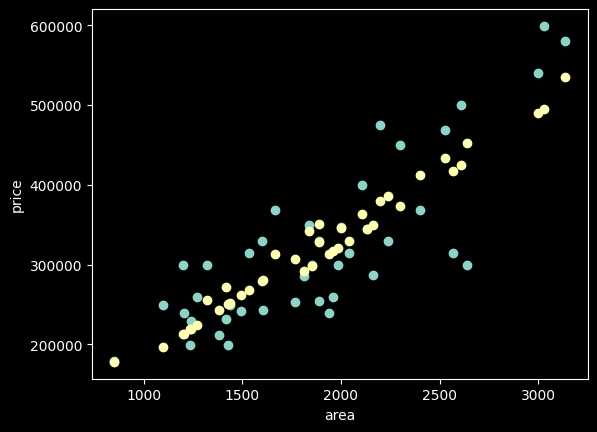

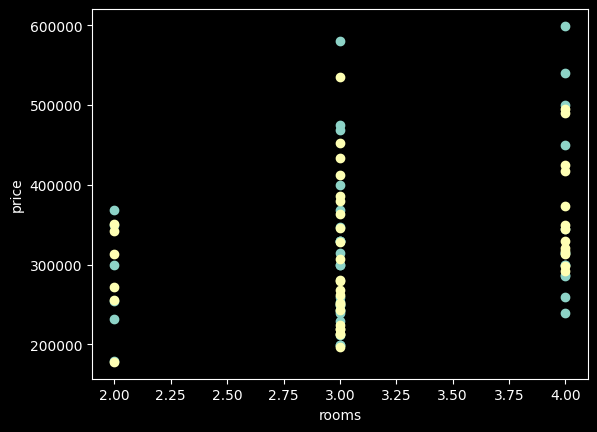

In [121]:
plt.figure()
plt.scatter(df_clean['area'], y)
plt.scatter(df_clean['area'], predicted)
plt.xlabel('area')
plt.ylabel('price')
plt.show()

plt.figure()
plt.scatter(df_clean['rooms'], y)
plt.scatter(df_clean['rooms'], predicted)
plt.xlabel('rooms')
plt.ylabel('price')
plt.show()

In [122]:
new_houses = pd.DataFrame({
    'area':  [2567, 1200, 852, 1852, 1203],
    'rooms': [5, 2, 5, 2, 3]
})

predictions = model.predict(new_houses)
print(predictions)

[394179.37522545 236130.94460054 108524.3678436  344729.8162116
 213416.37871077]
